# Машинное обучение, ФКН ВШЭ

# Практическое задание 10. Рекомендательные системы

## Общая информация
**Дата выдачи: 24.03.2026**

**Мягкий дедлайн: 10.04.2026 23:59 MSK**

**Жёсткий дедлайн: 18.04.2026 23:59 MSK** 

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — **11** баллов + **2.5** бонусных.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-10-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

## О задании

В этой работе мы будем решать задачу рекомендации музыки (звуууук). То есть мы поставим целью получить модель, которая для каждого пользователя будет возвращать набор треков, наиболее похожих на те, что он уже слушал. В первой части мы разберемся с memory-based подходом и моделью со скрытыми переменными. Это не очень мощные методы, но зато они позволяют строить предсказания почти моментально. Затем, во второй части, мы обратим внимание на то, что датасет содержит огромное число треков и воспользуемся результатами уже построенных быстрых моделей для сокращения списка кандидатов до разумного количества. После этого проведем ранжирование среди кандидатов с помощью сильной, но чуть более медленной модели, и отберем самые лучшие варианты. Такой двухэтапный алгоритм построения рекомендаций изображен на картинке.


![](https://i.ibb.co/4RptSVjp/Screenshot-2026-03-23-at-00-29-18.png)

Приступим!

Все шаблоны ниже можно переписывать по своему усмотрению.

---
P.S. в части, где мы реализуем SGD и ALS результаты могут разниться от запуска к запуску из-за случайной реализации матриц P и Q

---

In [2]:
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from typing import Callable, List

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as scs

In [3]:
ratings = pd.read_csv('/kaggle/input/datasets/shaykoaleksandr/zvuuuk/music_dataset.csv')
ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [4]:
tracks_info = pd.read_csv('/kaggle/input/datasets/shaykoaleksandr/zvuuuk/tracks_info.csv')
tracks_info.head()

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']
4,4,Boom Boom Pow,['Black Eyed Peas']


Для оценки качества рекомендаций мы будем использовать метрику $MAP@k$.

$$
MAP@k = \frac{1}{N} \sum_{u = 1}^N AP_u@k
$$
$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)$$


*   $N$ - количество пользователей.
*   $n_u$ - число релевантных треков пользователя $u$ на тестовом промежутке.
*   $r_u(i)$ - бинарная величина: относится ли трек на позиции $i$ к релевантным.

**Задание 1 (0.5 балл).** Реализуйте метрику $MAP@k$.

In [5]:
def mapk(relevant: List[List[int]], predicted: List[List[int]], k: int = 20):
    # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
    mapk = 0
    for i in range(len(predicted)):
        ap = 0
        rels = 0
        rels_set = set(relevant[i])
        for j in range(min(k, len(predicted[i]))):
            if predicted[i][j] in rels_set:
                rels += 1
                ap += rels/(j + 1)
        ap/= min(k, len(relevant[i]))
        mapk += ap
    return mapk/len(relevant)

In [6]:
relevant = [
    [1, 7, 6, 2, 8],
    [1, 5, 4, 8],
    [8, 2, 5]
]

pred = [
    [8, 1, 5, 0, 7, 2, 9, 4],
    [0, 1, 8, 5, 3, 4, 7, 9],
    [9, 2, 0, 6, 8, 5, 3, 7]
]

assert round(mapk(relevant, pred, k=5), 4) == 0.4331

Разделим данные на тренировочные и тестовые так, чтобы в теcтовый датасет попали 50 последних треков каждого пользователя.

In [7]:
def train_test_split(ratings):
    train_ratings, test_ratings = [], []
    num_test_samples = 50

    for userId, user_data in tqdm(ratings.groupby('userId')):
        train_ratings += [user_data[:-num_test_samples]]

    train_ratings = pd.concat(train_ratings).reset_index(drop=True)
    all_train_items = train_ratings['trackId'].unique()

    # getting train samples
    # we drop all tracks that are not presented it the training samples,
    # because we won't be able to learn representations for them
    for userId, user_data in tqdm(ratings.groupby('userId')):
        test_items = user_data[-num_test_samples:]
        test_items = test_items[np.isin(test_items['trackId'], all_train_items)]
        test_ratings += [test_items]

    test_ratings = pd.concat(test_ratings).reset_index(drop=True)

    return train_ratings, test_ratings

In [8]:
train_ratings, test_ratings = train_test_split(ratings)

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

Почистим табличку с информацией о треках и закодируем id треков так, чтобы они соответствовали их порядковому номеру.

In [9]:
redundant_rows = np.where(~np.isin(tracks_info['id'], train_ratings['trackId'].unique()))[0]
tracks_info.drop(redundant_rows, inplace=True)
tracks_info = tracks_info.reset_index(drop=True)

In [10]:
def ids_encoder(ratings):
    users = sorted(ratings['userId'].unique())
    items = sorted(ratings['trackId'].unique())

    # create users and items encoders
    uencoder = LabelEncoder()
    iencoder = LabelEncoder()

    # fit users and items ids to the corresponding encoder
    uencoder.fit(users)
    iencoder.fit(items)

    return uencoder, iencoder

In [11]:
uencoder, iencoder = ids_encoder(train_ratings)
train_ratings['trackId'] = iencoder.transform(train_ratings['trackId'].tolist())
test_ratings['trackId'] = iencoder.transform(test_ratings['trackId'].tolist())
tracks_info['id'] = iencoder.transform(tracks_info['id'].tolist())

In [12]:
train_ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [13]:
test_ratings.head()

,userId,trackId
0,0,57582
1,0,57802
2,0,57957
3,0,58174
4,0,59168


Соберем все релевантные треки для каждого пользователя в список.

In [14]:
test_relevant = []
test_users = []
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant += [user_data['trackId'].tolist()]
    test_users.append(user_id)

**Задание 2 (0.5 балла).** Реализуйте метод `get_test_recommendations` в классе `BaseModel`. Он принимает на вход параметр `k` и возвращает массив из `k` наиболее подходящих треков для каждого пользователя. Не забывайте удалять уже прослушанные треки из рекомендуемых.

In [15]:
class BaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = np.zeros((self.n_users, self.n_items))
        self.R[self.ratings['userId'], self.ratings['trackId']] = 1.
        
    def recommend(self, uid: int):
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_preds = []

        all_preds = []

        for user_id in range(self.n_users):
            all_preds.append(self.recommend(user_id))
            
        test_preds = self.remove_train_items(all_preds, k)
        
        # your code here: (￣▽￣)/♫•*¨*•.¸¸♪

        return test_preds[test_users]

### Часть 1. Коллаборативная фильтрация (User2User)

Идея: чтобы выбрать треки, которые понравятся пользователю, можно набрать несколько похожих на него пользователей (соседей) и посмотреть, какие треки они слушают. После этого остается агрегировать треки этих пользователей и выбрать самые популярные. Соответственно, задача состоит из двух частей: выбора функции похожести двух пользователей и способа агрегации.

В качестве функции похожести мы будем использовать меру Жаккара:

$$ s(u, v) = \frac{|I_u \cap I_v|}{|I_u \cup I_v|} $$


Во всех формулах 
* $I_u$ - множество треков, прослушанных пользователем $u$.
* $r_{ui}$ - прослушал ли пользователь $u$ трек $i$ (0 или 1).

Множество соседей определим как $$N(u) = \{ v \in U \setminus \{u\} \mid s(u, v) > \alpha\},$$ где $\alpha \, - $ гиперпараметр.



Для агрегации мы будем пользоваться следующей формулой.
$$
\hat{r}_{ui} = \frac{\sum_{v \in N(u)} s(u, v) r_{vi}}{\sum_{v \in N(u)} |s(u, v)|}
$$

**Задание 3.2 (0.5 балла).** Реализуйте функцию подсчета меры Жаккара.

Функция принимает матрицу оценок и вектор оценок пользователя $u$ и возвращает вектор со значениями похожести пользователя $u$ на всех пользователей. Старайтесь писать оптимизированный код, за неэффективную реализацию оценка может быть снижена.

In [16]:
def jaccard(ratings: np.array, user_vector: np.array) -> np.array:
    # your code here: (￣▽￣)/♫•*¨*•.¸¸♪

    track_matched = np.sum(ratings * user_vector, axis=1)
    track_total = np.sum(ratings + user_vector - ratings * user_vector, axis=1)
    return track_matched/track_total

**Задание 4 (1 балл).** Реализуйте методы `similarity` и `recommend` класса `User2User`. `recommend` возвращает индексы треков, отсортированные в порядке убывания предсказанных оценок. Значение параметра `alpha` можно менять по своему усмотрению так, чтобы оно было разумным.

In [17]:
class User2User(BaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)

        self.similarity_func = jaccard
        self.alpha = 0.02

    def similarity(self, user_vector: np.array):
        """
        user_vector: [n_items]
        """
        # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
        return self.similarity_func(self.R, user_vector)
        
        
    def recommend(self, uid: int):
        # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
        similars = self.similarity(self.R[uid])
        mask = similars >= self.alpha
        similars = similars[mask]
        neighbors = self.R[mask]
        r_uis = np.sum(similars[:, None] * neighbors, axis=0) / np.sum(similars)
        return np.argsort(-r_uis)

**Задание 5 (0.5 балл).** Постройте график зависимости значений $MAP@k$ от разных $k$ при рекомендации на основе меры Жаккара, сравните его с рекомендациями самых популярных треков и случайных. Какой из трех способов рекомендаций оказался лучшим?

/tmp/ipykernel_55/3597987971.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


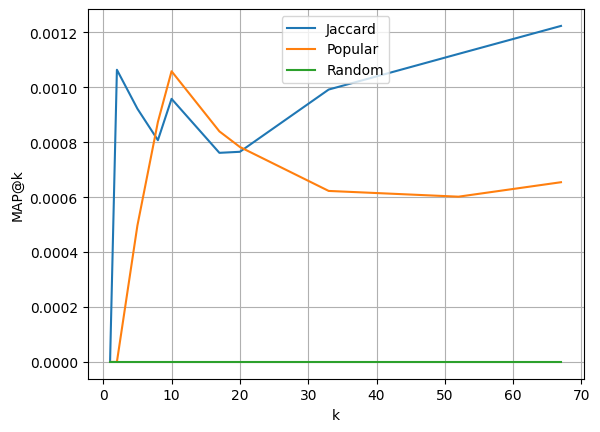

In [18]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪
k_vals = [1, 2, 5, 8, 10, 17, 20, 33, 52, 67]
obj = User2User(train_ratings)

most_popular = train_ratings['trackId'].value_counts().index.to_numpy()
popular_preds = np.tile(most_popular, (obj.n_users, 1))
popular_test_preds = obj.remove_train_items(popular_preds, max(k_vals))[test_users]

gen_rand = np.random.default_rng(67)
random_preds = np.zeros((obj.n_users, obj.n_items), dtype=int)
all_tracks = np.arange(obj.n_items)
for user_id in range(obj.n_users):
    random_preds[user_id] = gen_rand.permutation(all_tracks)
random_test_preds = obj.remove_train_items(random_preds, max(k_vals))[test_users]

mapk_jac_vals = []
mapk_pop_vals = []
mapk_rand_vals = []

jac_preds = obj.get_test_recommendations(max(k_vals))

for k in k_vals:
    mapk_jac_vals.append(mapk(test_relevant, jac_preds, k))
    mapk_pop_vals.append(mapk(test_relevant, popular_test_preds, k))
    mapk_rand_vals.append(mapk(test_relevant, random_test_preds, k))

plt.plot(k_vals, mapk_jac_vals, label='Jaccard')
plt.plot(k_vals, mapk_pop_vals, label='Popular')
plt.plot(k_vals, mapk_rand_vals, label='Random')
plt.xlabel('k')
plt.ylabel('MAP@k')
plt.legend()
plt.grid(True)
plt.show()

---
По графикам видно, что случайные рекомендации всегда дают значения метрики, близкие к нулю, что ожидаемо: треков много, и вероятность случайно угадать именно те композиции, которые пользователь послушал в тестовом периоде, очень мала.

Рекомендация самых популярных треков показывает намного лучшее качество и на промежутке примерно от 10 до 20 даже обгоняет Жаккара. Это можно объяснить тем, что популярные треки часто встречаются в прослушиваниях разных пользователей, поэтому просто сама вероятность попадания в релевантные треки у такого подхода высокая.

Однако в целом Жаккар показывает лучшие результаты, особенно при малых и больших k. При малых k это важно, потому что метрика сильно зависит от качества самых первых рекомендаций, а персонализированный подход за счет учета похожих по прослушиваниям пользователей лучше поднимает релевантные треки наверх списка. При больших k Жаккар также выигрывает, поскольку лучше учитывает индивидуальные предпочтения пользователя через похожих соседей и в итоге покрывает больше релевантных треков, чем глобально популярный подход.

---

**Бонус (1 балла).** Как вы могли заметить, матрица оценок получается очень разреженной, но мы работаем с ней как с обычной, это не дело. Перепишите код так, чтобы все методы могли работать с разреженными матрицами и сравните скорость работы такого подхода с оригинальным.

In [19]:
# your code here: ‿︵‿︵ヽ(°□° )ノ︵‿︵‿
from scipy.sparse import csr_matrix

class BaseModelSparse:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        rows = self.ratings['userId'].to_numpy()
        cols = self.ratings['trackId'].to_numpy()
        data = np.ones(len(self.ratings), dtype=np.float32)

        self.R = csr_matrix((data, (rows, cols)), shape=(self.n_users, self.n_items))
        
    def recommend(self, uid: int):
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_preds = []

        all_preds = []

        for user_id in range(self.n_users):
            all_preds.append(self.recommend(user_id))
            
        test_preds = self.remove_train_items(all_preds, k)
        
        # your code here: (￣▽￣)/♫•*¨*•.¸¸♪

        return test_preds[test_users]

In [20]:
class User2UserSparse(BaseModelSparse):
    def __init__(self, ratings):
        super().__init__(ratings)

        self.similarity_func = jaccard_sparse
        self.alpha = 0.02

    def similarity(self, user_vector: np.array):
        """
        user_vector: [n_items]
        """
        # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
        return self.similarity_func(self.R, user_vector)
        
        
    def recommend(self, uid: int):
        # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
        similars = self.similarity(self.R[uid])
        mask = similars >= self.alpha
        similars = similars[mask]
        neighbors = self.R[mask]
        r_uis = neighbors.T.dot(similars) / np.sum(similars)
        r_uis = np.asarray(r_uis).ravel()
        return np.argsort(-r_uis)

In [21]:
def jaccard_sparse(ratings: np.array, user_vector: np.array) -> np.array:
    # your code here: (￣▽￣)/♫•*¨*•.¸¸♪

    track_matched = ratings.dot(user_vector.T).toarray().ravel()
    track_total = ratings.getnnz(axis=1) + user_vector.getnnz() - track_matched
    return track_matched/track_total

Как мы сейчас увидим, скорость и вправду выросла просто бешено

In [22]:
import time

k = 20

start = time.time()
dense_model = User2User(train_ratings)
dense_preds = dense_model.get_test_recommendations(k)
dense_time = time.time() - start

start = time.time()
sparse_model = User2UserSparse(train_ratings)
sparse_preds = sparse_model.get_test_recommendations(k)
sparse_time = time.time() - start

print(f'Dense time:  {dense_time} sec')
print(f'Sparse time: {sparse_time} sec')

/tmp/ipykernel_55/3597987971.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


Dense time:  47.62198543548584 sec
Sparse time: 0.8080155849456787 sec


/tmp/ipykernel_55/4183038939.py:32: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


---
Просто проверим, что мы все правильно сделали и в обоих случаях получаем одинаковый результат:

---

In [23]:
print(mapk(test_relevant, dense_preds, 20))
print(mapk(test_relevant, sparse_preds, 20))

0.0007651166464979787
0.0007651166464979787


Мы можем посмотреть глазами, насколько хорошо модель рекомендует треки. Для этого сравним уже прослушанные треки с рекомендованными и релевантными для случайного пользователя. Хорошо ли у вас получилось?

In [24]:
user_id = np.random.randint(0, obj.n_users)

In [25]:
listened_tracks = train_ratings[train_ratings.userId == user_id].trackId[:15]

print('Already listened tracks:')

tracks_info.loc[listened_tracks][['name', 'artists']]

Already listened tracks:


,name,artists
851,Happy New Year,['ABBA']
1033,Somebody's Watching Me,['Rockwell']
1890,Кончится лето,['КИНО']
1950,Белая,['Сурганова и Оркестр']
2043,Мураками,['Сурганова и Оркестр']
2071,Снег идёт,"[""Глюк'oZa""]"
2481,Gangsta's Paradise,"['Coolio', 'L.V.']"
5361,Новый год в постели,['Чи-Ли']
5636,Россия,['Баста']
5941,Свобода,['Ленинград']


In [26]:
preds = obj.get_test_recommendations(15)

print('Predicted tracks:')

tracks_info.loc[preds[user_id]][['name', 'artists']]

Predicted tracks:


/tmp/ipykernel_55/3597987971.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


,name,artists
52811,Девочка в тренде,['Miko']
14484,Прогулки по воде,['Nautilus Pompilius']
25797,Этот город,['Браво']
27822,Звезда по имени Солнце,"['Игорь Вдовин', 'Виктор Цой']"
9438,Что такое осень,['ДДТ']
8010,Je veux,['Zaz']
19157,Для тебя,['Звери']
27805,Как на войне,['Агата Кристи']
41486,Наши юные смешные голоса,['Ногу свело!']
52075,Kукушка,['Полина Гагарина']


In [27]:
test_tracks = test_ratings[test_ratings.userId == user_id].trackId[:15]

print('Test-time tracks:')

tracks_info.loc[test_tracks][['name', 'artists']]

Test-time tracks:


,name,artists
63287,ПАЦАНЫ II,['GONE.Fludd']
63343,Поколение,['Kara Kross']
63361,Худшая,['Асия']
63378,Бог проклятых,['Би-2']
63419,Russian Cyberfolk Song,"['Liliana Bush', 'Daria Scherbak', 'Ensemble V..."
63438,невывоЗИМАя,['NILETTO']
63446,Пьяную домой,['Клава Кока']
63489,Не убегай,['NIZAM']
63500,Обращение к 2020 году,['Даня Милохин']
63560,В последний раз,['Idris & Leos']


В целом модель улавливает основные предпочтения юзера, особенно в сегменте русского рока, и предлагает близкие по стилю треки. Однако рекомендации все равно не остаются в одном стиле - модель смешивает разные жанры и эпохи, из-за чего часть треков выглядит менее релевантной к этому пользователю. Таким образом, модель уже выделяет структуру вкуса, но делает это пока недостаточно точно.

### Часть 2. Модель со скрытыми переменными: ALS

В этой части мы пощупаем метод рекомендаций со скрытыми переменными.
Идея: будем предсказывать оценки по формуле
$$
\hat{r}_{ui} = \langle p_u, q_u \rangle,
$$
$p_u \in \mathbb{R}^d$ и $q_i \in \mathbb{R}^d$ - латентные векторы пользователя $u$ и объекта $i$ соответственно. 

Оптимизировать мы будем MSE между истинной оценкой пользователя и предсказанной с регуляризацией
$$
L = \sum_{(u, i) \in R} (\hat{r}_{ui} - r_{ui})^2 + \lambda \left(\sum_{u \in U} \|p_u\|^2 + \sum_{i \in I} \|q_i\|^2\right)
$$

__P. S.__ Заметьте, что описанная модель предназначена для работы только с __явной__ информацией. В нашем случае от модели будет требоваться всегда возвращать 1, так как мы считаем ошибку только по парам, о которых получили фидбек. Поэтому логично подумать, что постановка задачи не имеет смысла. Однако, на практике оказывается, что из-за случайности в инициализации матриц $P$ и $Q$, обученные векторы для всех треков и пользователей в конце обучения получаются разными. Поэтому модель все же не лишена смысла.

__P. P. S.__ Для более разумной работы с неявной информацией был предложен метод iALS, его описание можно найти в лекции. Ниже будет бонус на его реализацию.

**Задание 6 (0.5 балла).** На лекции рассматривались два подхода к оптимизации параметров. Можно это делать обычным стохастическим градинтным спуском, а можно по очереди обновлять матрицы $P, Q$, и тогда получится метод Alternating Least Squares (ALS). Выведите формулы обновления параметров для обоих методов.

**SGD:**

Ответ



**ALS:**

Ответ



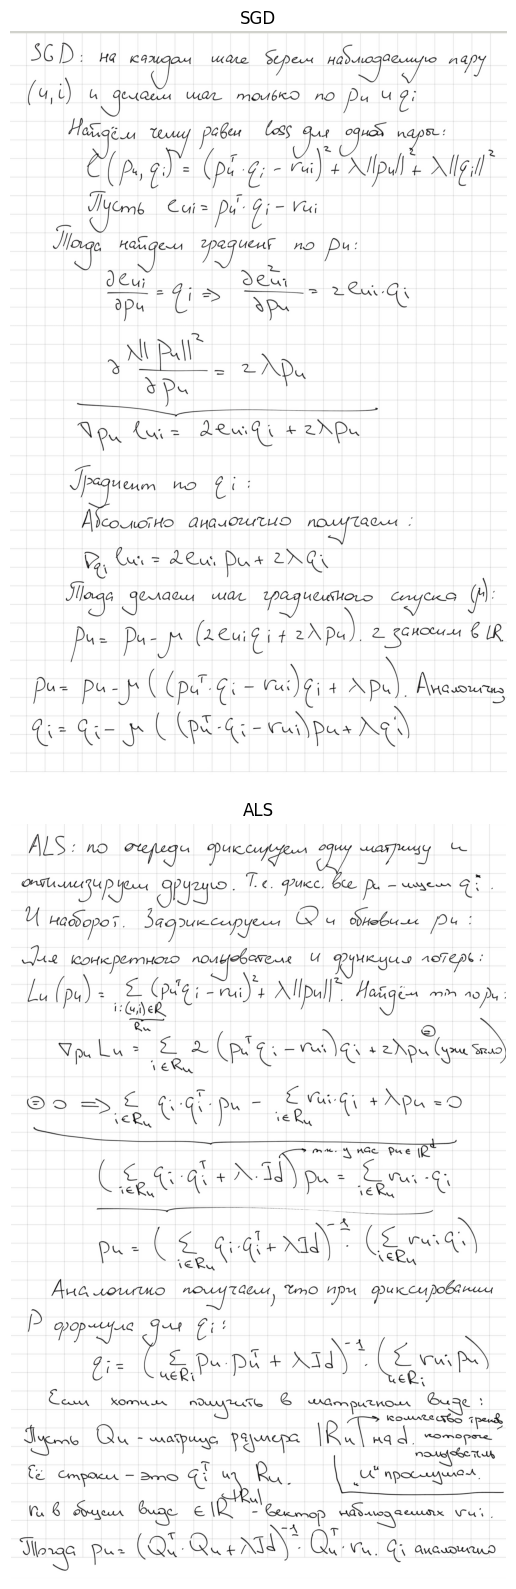

In [28]:
import matplotlib.pyplot as plt
from PIL import Image

img1 = Image.open('//kaggle/input/datasets/shaykoaleksandr/optimizers/1000009213.jpg')
img2 = Image.open('/kaggle/input/datasets/shaykoaleksandr/optimizers/1000009215.jpg')

fig, axes = plt.subplots(2, 1, figsize=(12, 16))

axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title('SGD')

axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title('ALS')

plt.tight_layout()
plt.show()

**Задание 7 (1.5 балла).** Реализуйте методы оптимизации параметров для обоих алгоритмов.

In [29]:
class LatentFactorModel(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd'):
        super().__init__(ratings)
        self.dim = dim
        
        assert mode in ['sgd', 'als']
        self.mode = mode

        self.P = np.random.normal(size=(self.n_users, dim))
        self.Q = np.random.normal(size=(self.n_items, dim))

        self.lr = 0.0003
        self.lamb = 0.01

    def fit(self, num_iters=5):
        for epoch in tqdm(range(num_iters)):

            if self.mode == 'sgd':
                # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
                shuffled = self.ratings.sample(frac=1).reset_index(drop=True)
                users = shuffled['userId'].to_numpy()
                items = shuffled['trackId'].to_numpy()
                
                for u, i in zip(users, items):
                    q_i = self.Q[i]
                    p_u = self.P[u]
                    r_ui_hat = p_u @ q_i
                    e_ui = r_ui_hat - 1
                    p_u_temp = p_u.copy()
                    p_u-= self.lr * (e_ui * q_i + self.lamb * p_u)
                    q_i-= self.lr * (e_ui * p_u_temp + self.lamb * q_i)
                    self.P[u] = p_u
                    self.Q[i] = q_i

            elif self.mode == 'als':
                # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
                I = np.eye(self.dim)
                
                for user_id, tracks in self.ratings.groupby('userId'):
                    listened_tracks = tracks['trackId'].unique()
                    sub_Q_u = self.Q[listened_tracks]
                    ones = np.ones(len(listened_tracks))
                    A = sub_Q_u.T @ sub_Q_u + self.lamb * I
                    b = sub_Q_u.T @ ones
                    self.P[user_id] = np.linalg.solve(A, b)
                    
                for track_id, users in self.ratings.groupby('trackId'):
                    listened_users = users['userId'].unique()
                    sub_P_i = self.P[listened_users]
                    ones = np.ones(len(listened_users))
                    A = sub_P_i.T @ sub_P_i + self.lamb * I
                    b = sub_P_i.T @ ones
                    self.Q[track_id] = np.linalg.solve(A, b)
                    
    def recommend(self, uid):
        pred_rating = self.P[uid] @ self.Q.T

        return np.argsort(pred_rating)[::-1]

**Задание 8 (1 балл).** Для обоих алгоритмов подберите оптимальные значения размерности скрытого пространства $d$ и размера предсказания $k$. Как изменяется качество предсказаний с числом итераций обучения? Постройте соответствующие графики, сравните со случайным подходом и User2User, сделайте выводы. Какой алгоритм вам кажется более подходящим для данной задачи и почему?

__P. S.__ Хотя бы один из методов обучения должен приводить к лучшим результатам в сравнении с User2User подходом.

__P. P. S.__ Методу SGD свойственно переобучаться, поэтому при подборе параметров полезно смотреть на значения ошибки и оптимизируемой метрики на тренировочном датасете. Вы также можете менять начальную инициализацию и прочие параметры, за исключением архитектуры, на ваш вкус.

/tmp/ipykernel_55/3597987971.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

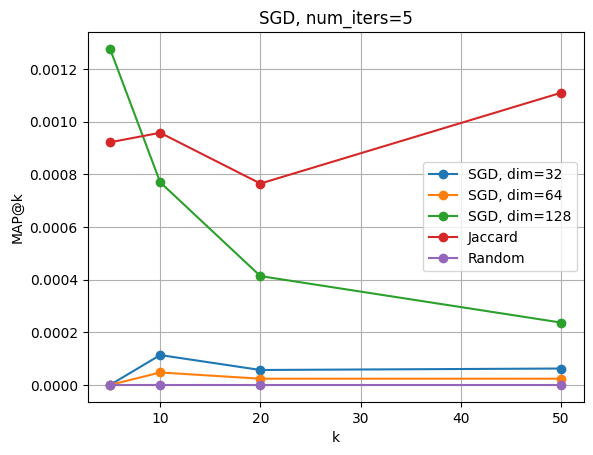

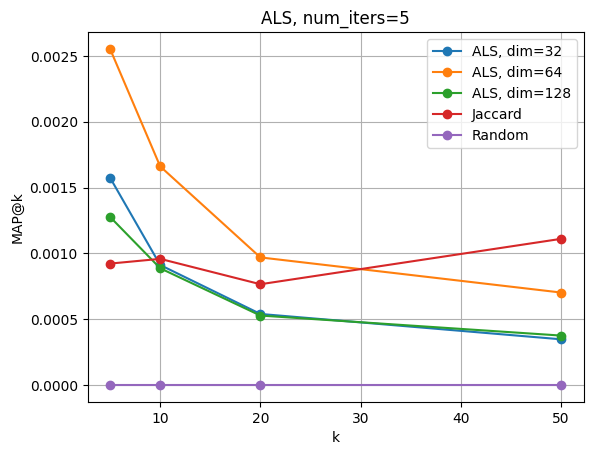

Best SGD: dim=128, k=5, num_iters=7, MAP@k=0.0017021276595744683
Best ALS: dim=128, k=5, num_iters=3, MAP@k=0.004453900709219858


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

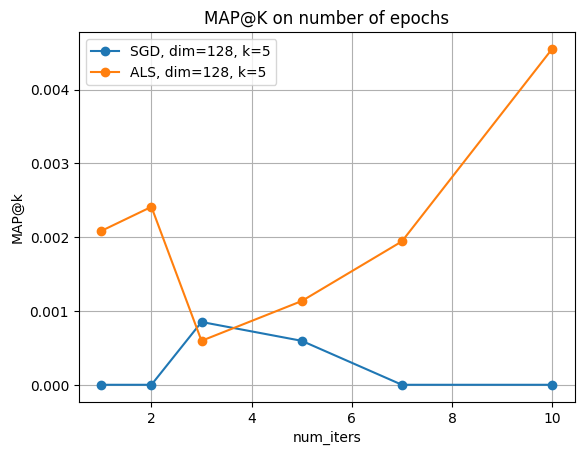

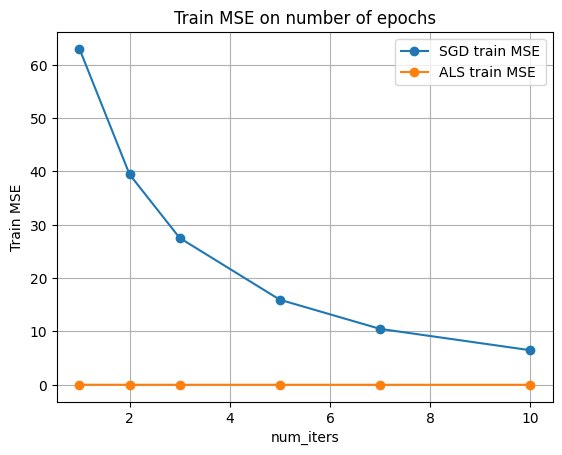

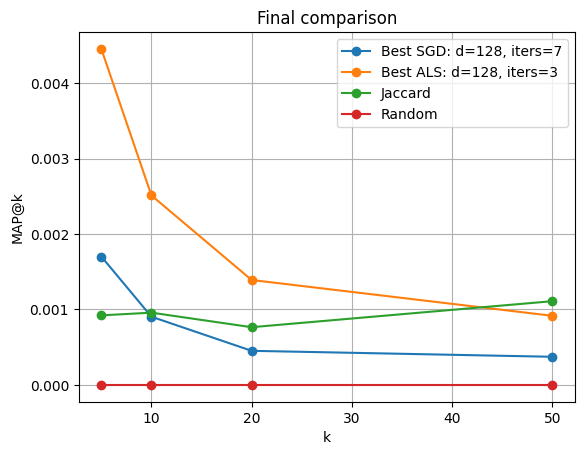

In [30]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪
def mse_on_train(model, ratings):
    users = ratings['userId'].to_numpy()
    items = ratings['trackId'].to_numpy()
    preds = np.sum(model.P[users] * model.Q[items], axis=1)
    return np.mean((preds - 1) ** 2)

dims = [32, 64, 128]
k_vals = [5, 10, 20, 50]
epoch_vals = [1, 2, 3, 5, 7, 10]

obj = User2User(train_ratings)

gen_rand = np.random.default_rng(67)
random_preds = np.zeros((obj.n_users, obj.n_items), dtype=int)
all_tracks = np.arange(obj.n_items)
for user_id in range(obj.n_users):
    random_preds[user_id] = gen_rand.permutation(all_tracks)
random_test_preds = obj.remove_train_items(random_preds, max(k_vals))[test_users]

mapk_jac_vals = []
mapk_rand_vals = []

jac_preds = obj.get_test_recommendations(max(k_vals))

for k in k_vals:
    mapk_jac_vals.append(mapk(test_relevant, jac_preds, k))
    mapk_rand_vals.append(mapk(test_relevant, random_test_preds, k))

sgd_scores = {}
als_scores = {}

best_sgd_score = -1
best_sgd_dim = None
best_sgd_k = None
best_sgd_epoch = None
best_sgd_preds = None

best_als_score = -1
best_als_dim = None
best_als_k = None
best_als_epoch = None
best_als_preds = None


for d in dims:
    for num_iters in epoch_vals:
        latent_model_sgd = LatentFactorModel(train_ratings, dim=d, mode='sgd')
        latent_model_sgd.fit(num_iters=num_iters)
        lat_sgd_test_preds = latent_model_sgd.get_test_recommendations(max(k_vals))

        latent_model_als = LatentFactorModel(train_ratings, dim=d, mode='als')
        latent_model_als.fit(num_iters=num_iters)
        lat_als_test_preds = latent_model_als.get_test_recommendations(max(k_vals))

        mapk_sgd = []
        mapk_als = []

        for k in k_vals:
            sgd_val = mapk(test_relevant, lat_sgd_test_preds, k)
            als_val = mapk(test_relevant, lat_als_test_preds, k)

            mapk_sgd.append(sgd_val)
            mapk_als.append(als_val)

            if sgd_val > best_sgd_score:
                best_sgd_score = sgd_val
                best_sgd_dim = d
                best_sgd_k = k
                best_sgd_epoch = num_iters
                best_sgd_preds = lat_sgd_test_preds.copy()

            if als_val > best_als_score:
                best_als_score = als_val
                best_als_dim = d
                best_als_k = k
                best_als_epoch = num_iters
                best_als_preds = lat_als_test_preds.copy()

        sgd_scores[(d, num_iters)] = mapk_sgd
        als_scores[(d, num_iters)] = mapk_als

fixed_epoch = 5

for d in dims:
    plt.plot(k_vals, sgd_scores[(d, fixed_epoch)], marker='o', label=f'SGD, dim={d}')
plt.plot(k_vals, mapk_jac_vals, marker='o', label='Jaccard')
plt.plot(k_vals, mapk_rand_vals, marker='o', label='Random')
plt.xlabel('k')
plt.ylabel('MAP@k')
plt.title(f'SGD, num_iters={fixed_epoch}')
plt.legend()
plt.grid(True)
plt.show()

for d in dims:
    plt.plot(k_vals, als_scores[(d, fixed_epoch)], marker='o', label=f'ALS, dim={d}')
plt.plot(k_vals, mapk_jac_vals, marker='o', label='Jaccard')
plt.plot(k_vals, mapk_rand_vals, marker='o', label='Random')
plt.xlabel('k')
plt.ylabel('MAP@k')
plt.title(f'ALS, num_iters={fixed_epoch}')
plt.legend()
plt.grid(True)
plt.show()

print(f'Best SGD: dim={best_sgd_dim}, k={best_sgd_k}, num_iters={best_sgd_epoch}, MAP@k={best_sgd_score}')
print(f'Best ALS: dim={best_als_dim}, k={best_als_k}, num_iters={best_als_epoch}, MAP@k={best_als_score}')

sgd_epoch_mapk = []
als_epoch_mapk = []

sgd_epoch_mse = []
als_epoch_mse = []

for num_iters in epoch_vals:
    latent_model_sgd = LatentFactorModel(train_ratings, dim=best_sgd_dim, mode='sgd')
    latent_model_sgd.fit(num_iters=num_iters)
    lat_sgd_test_preds = latent_model_sgd.get_test_recommendations(max(k_vals))

    latent_model_als = LatentFactorModel(train_ratings, dim=best_als_dim, mode='als')
    latent_model_als.fit(num_iters=num_iters)
    lat_als_test_preds = latent_model_als.get_test_recommendations(max(k_vals))

    sgd_epoch_mapk.append(mapk(test_relevant, lat_sgd_test_preds, best_sgd_k))
    als_epoch_mapk.append(mapk(test_relevant, lat_als_test_preds, best_als_k))

    sgd_epoch_mse.append(mse_on_train(latent_model_sgd, train_ratings))
    als_epoch_mse.append(mse_on_train(latent_model_als, train_ratings))

plt.plot(epoch_vals, sgd_epoch_mapk, marker='o', label=f'SGD, dim={best_sgd_dim}, k={best_sgd_k}')
plt.plot(epoch_vals, als_epoch_mapk, marker='o', label=f'ALS, dim={best_als_dim}, k={best_als_k}')
plt.xlabel('num_iters')
plt.ylabel('MAP@k')
plt.title('MAP@K on number of epochs')
plt.legend()
plt.grid(True)
plt.show()


plt.plot(epoch_vals, sgd_epoch_mse, marker='o', label='SGD train MSE')
plt.plot(epoch_vals, als_epoch_mse, marker='o', label='ALS train MSE')
plt.xlabel('num_iters')
plt.ylabel('Train MSE')
plt.title('Train MSE on number of epochs')
plt.legend()
plt.grid(True)
plt.show()

best_sgd_mapk = []
best_als_mapk = []

for k in k_vals:
    best_sgd_mapk.append(mapk(test_relevant, best_sgd_preds, k))
    best_als_mapk.append(mapk(test_relevant, best_als_preds, k))

plt.plot(k_vals, best_sgd_mapk, marker='o', label=f'Best SGD: d={best_sgd_dim}, iters={best_sgd_epoch}')
plt.plot(k_vals, best_als_mapk, marker='o', label=f'Best ALS: d={best_als_dim}, iters={best_als_epoch}')
plt.plot(k_vals, mapk_jac_vals, marker='o', label='Jaccard')
plt.plot(k_vals, mapk_rand_vals, marker='o', label='Random')
plt.xlabel('k')
plt.ylabel('MAP@k')
plt.title('Final comparison')
plt.legend()
plt.grid(True)
plt.show()

---
Итак, по графикам мы можем сказать следующее:

Во-первых, SGD проигрывает Жаккару практически при любом значении dim и k во всех наших конфигурациях (даже в лучшей для SGD), видимо потому что локально обновлять одну пару может быть слишком зашумленно и плохо угадывать общее направление треков, которые слушает пользователь. Поэтому при любом k он показывает низкие результаты по MAP@k, то есть рекомендует довольно слабо. Также по MSE на трейне мы тоже видим, что чем больше эпох, тем SGD и вправду имеет меньшую ошибку и при этом MAP@k на тесте тоже падает, то есть, он переобучается, учитывая, что мы взяли dim = 128. По сути самый большой и дает переобучение

Что касается ALS, то здесь мы получаем намного лучшее качество рекомендации, которое причем почти всегда обходит Жаккара в своей лучшей версии. Это объясняется скорее всего тем, здесь для вектора p_u и q_i в оптимизациях мы используем все треки пользователя, а также всех пользователей для данного трека, что позволяет обучаться с меньшим шумом и лучше угадывать общие направления по пользователям и трекам. Причем тут удалось быстро сойтись к минимуму и уже всего за 3 эпохи мы получили лучшее качество. Ну и соответственно уж с таким обучением крутым неудивительно, что мы получили довольно хорошие рекомендации относительно остальных моделей.

---

Если у вас получилось достаточно хорошее качество, то при оптимизации параметров марицы $Q$ похожим трекам стали соответствовать похожие векторы. Поэтому мы можем для любого трека найти наиболее близкие к нему в латентном пространстве и проверить степерь обученности модели вручную.

In [31]:
example_trackId = tracks_info[tracks_info.name == 'Выхода нет'].iloc[0].id

model = LatentFactorModel(train_ratings, dim=best_als_dim, mode='als')
model.fit(num_iters=best_als_epoch)

preds = model.Q @ model.Q[example_trackId]
preds = preds / np.sqrt((model.Q**2).sum(axis=1) + 1e-8)

track_idxs = preds.argsort()[::-1][:20]

  0%|          | 0/3 [00:00<?, ?it/s]

In [32]:
similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']]
similar_tracks['similarity'] = preds[track_idxs] / np.linalg.norm(model.Q[example_trackId])
similar_tracks

,name,artists,similarity
5512,Выхода нет,['Сплин'],1.000000
2058,Последний герой,['КИНО'],0.766358
16224,Пока горит свеча,['Машина времени'],0.678974
5153,Stormbringer,['Deep Purple'],0.650202
9689,Bicycle Race,['Queen'],0.650202
16637,Zodiac,['Zodiac'],0.650202
5570,Моё сердце,['Сплин'],0.628508
14871,Никто не услышит (Ой-йо),['ЧайФ'],0.620030
2179,Восьмиклассница,['КИНО'],0.606529
13264,Безобразная Эльза,['Крематорий'],0.599280


По ближайшим соседям трека «Выхода нет» видно, что модель уловила не случайные связи, потому что среди похожих треков больше всего композиций русского и советского рока, а также частично классического англоязычного рока. Это говорит о том, что в латентном пространстве модель уже начала понимать жанровую и стилевую близость треков, а значит может использовать эти зависимости для построения разумных рекомендаций.

**Бонус (1.5 балла).**

Постройте модель iALS и сравните ее качество с обучением ALS и SGD.

In [33]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪
class LatentFactorModel(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd', alpha=40.0):
        super().__init__(ratings)
        self.dim = dim
        
        assert mode in ['sgd', 'als', 'ials']
        self.mode = mode

        self.P = np.random.normal(size=(self.n_users, dim))
        self.Q = np.random.normal(size=(self.n_items, dim))

        self.lr = 0.0003
        self.lamb = 0.01
        self.alpha = alpha

    def fit(self, num_iters=5):
        for epoch in tqdm(range(num_iters)):

            if self.mode == 'sgd':
                # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
                shuffled = self.ratings.sample(frac=1).reset_index(drop=True)
                users = shuffled['userId'].to_numpy()
                items = shuffled['trackId'].to_numpy()
                
                for u, i in zip(users, items):
                    q_i = self.Q[i]
                    p_u = self.P[u]
                    r_ui_hat = p_u @ q_i
                    e_ui = r_ui_hat - 1
                    p_u_temp = p_u.copy()
                    p_u-= self.lr * (e_ui * q_i + self.lamb * p_u)
                    q_i-= self.lr * (e_ui * p_u_temp + self.lamb * q_i)
                    self.P[u] = p_u
                    self.Q[i] = q_i

            elif self.mode == 'als':
                # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
                I = np.eye(self.dim)
                
                for user_id, tracks in self.ratings.groupby('userId'):
                    listened_tracks = tracks['trackId'].unique()
                    sub_Q_u = self.Q[listened_tracks]
                    ones = np.ones(len(listened_tracks))
                    A = sub_Q_u.T @ sub_Q_u + self.lamb * I
                    b = sub_Q_u.T @ ones
                    self.P[user_id] = np.linalg.solve(A, b)
                    
                for track_id, users in self.ratings.groupby('trackId'):
                    listened_users = users['userId'].unique()
                    sub_P_i = self.P[listened_users]
                    ones = np.ones(len(listened_users))
                    A = sub_P_i.T @ sub_P_i + self.lamb * I
                    b = sub_P_i.T @ ones
                    self.Q[track_id] = np.linalg.solve(A, b)
                    
            elif self.mode == 'ials':
                I = np.eye(self.dim)
                QtQ = self.Q.T @ self.Q

                for user_id, tracks in self.ratings.groupby('userId'):
                    listened_tracks = tracks['trackId'].unique()
                    sub_Q_u = self.Q[listened_tracks]
                    ones = np.ones(len(listened_tracks))
                    A = QtQ + self.alpha * (sub_Q_u.T @ sub_Q_u) + self.lamb * I
                    b = (1 + self.alpha) * sub_Q_u.T @ ones
                    self.P[user_id] = np.linalg.solve(A, b)

                PtP = self.P.T @ self.P

                for track_id, users in self.ratings.groupby('trackId'):
                    listened_users = users['userId'].unique()
                    sub_P_i = self.P[listened_users]
                    ones = np.ones(len(listened_users))
                    A = PtP + self.alpha * (sub_P_i.T @ sub_P_i) + self.lamb * I
                    b = (1 + self.alpha) * sub_P_i.T @ ones
                    self.Q[track_id] = np.linalg.solve(A, b)
                    
    def recommend(self, uid):
        pred_rating = self.P[uid] @ self.Q.T

        return np.argsort(pred_rating)[::-1]

In [34]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪

alpha_vals = [1, 10, 40]
dims_ials = [32, 64]
epoch_vals_ials = [2, 5, 10]
k_vals = [5, 10, 20, 50]

ials_scores = {}

best_ials_score = -1
best_ials_dim = None
best_ials_alpha = None
best_ials_epoch = None
best_ials_preds = None

for alpha in alpha_vals:
    for d in dims_ials:
        for num_iters in epoch_vals_ials:
            latent_model_ials = LatentFactorModel(
                train_ratings,
                dim=d,
                mode='ials',
                alpha=alpha
            )
            latent_model_ials.fit(num_iters=num_iters)
            lat_ials_test_preds = latent_model_ials.get_test_recommendations(max(k_vals))

            mapk_ials = []
            for k in k_vals:
                mapk_ials.append(mapk(test_relevant, lat_ials_test_preds, k))

            ials_scores[(alpha, d, num_iters)] = mapk_ials
            mean_ials_score = np.mean(mapk_ials)

            if mean_ials_score > best_ials_score:
                best_ials_score = mean_ials_score
                best_ials_dim = d
                best_ials_alpha = alpha
                best_ials_epoch = num_iters
                best_ials_preds = lat_ials_test_preds.copy()

print(f'Best iALS: alpha={best_ials_alpha}, dim={best_ials_dim}, num_iters={best_ials_epoch}, mean MAP@k={best_ials_score}')

  0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_55/3597987971.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Best iALS: alpha=1, dim=64, num_iters=5, mean MAP@k=0.002291911992110136


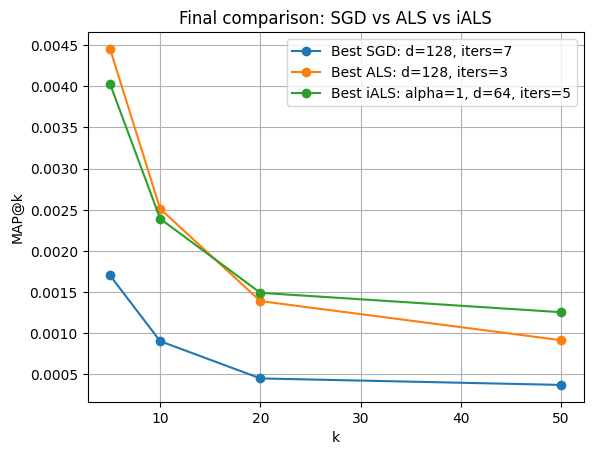

In [35]:
best_ials_mapk = []
for k in k_vals:
    best_ials_mapk.append(mapk(test_relevant, best_ials_preds, k))

plt.plot(k_vals, best_sgd_mapk, marker='o',
         label=f'Best SGD: d={best_sgd_dim}, iters={best_sgd_epoch}')
plt.plot(k_vals, best_als_mapk, marker='o',
         label=f'Best ALS: d={best_als_dim}, iters={best_als_epoch}')
plt.plot(k_vals, best_ials_mapk, marker='o',
         label=f'Best iALS: alpha={best_ials_alpha}, d={best_ials_dim}, iters={best_ials_epoch}')

plt.xlabel('k')
plt.ylabel('MAP@k')
plt.title('Final comparison: SGD vs ALS vs iALS')
plt.legend()
plt.grid(True)
plt.show()

---
Как мы видим, в целом iALS оказалась сильнее ALS при больших k, поскольку начинает учитывать не только прослушанные пользователем треки, но и непрослушанные как менее предпочтительные. За счет этого модель лучше понимает, в какую сторону нужно обновлять веса, и точнее настраивает латентные представления пользователей и треков. Поэтому рекомендации в итоге получаются более точными. Тем не менее, при маленьких k модель возможно просто улавливает шум из-за непрослушанных треков, а потому немного отклоняется от правильных рекомендаций.

---

### Часть 3. Второй уровень рекомендаций.

Выше мы построили простейшие модели, которые показывают не слишком высокое качество, но зато работают очень быстро. Воспользуемся ими для того, чтобы отобрать некоторое количество наиболее перспективных треков, которые мы сможем отранжировать уже более сложной моделью (в нашем случае это будет [CatBoost](https://catboost.ai/en/docs/concepts/python-reference_catboost)).

**Задание 9 (1 балл).**

Для каждого пользователя возьмите топ-100 рекомендованных треков от модели LFM (ALS или SGD на ваш выбор) и топ-100 от модели User2User. Это будут наши кандидаты, которые мы затем будем ранжировать бустингом.

In [36]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪

candidates = {}
top_100_recs_als = model.get_test_recommendations(100)
top_100_recs_u2u = obj.get_test_recommendations(100)

for num, user_id in enumerate(test_users):
    tracks_als = top_100_recs_als[num]
    tracks_u2u = top_100_recs_u2u[num]

    candidates[user_id] = list(set(tracks_als) | set(tracks_u2u))

/tmp/ipykernel_55/3597987971.py:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


**Задание 10 (2 балла).**

Подготовьте датасет для обучения модели ранжирования. Он должен состоять из пар: объект, целевая переменная. Объект - это пара (user, item) и всякие дополнительные признаки на их основе. Предлагается создать набор следующих признаков, однако вы можете добавлять свои по желанию, если они вам кажутся разумными:
 1) id пользователя
 1) id трека
 1) косинусное расстояние между эмбеддингами LFM соответствующих пользователя и трека
 1) среднее значение меры Жаккара между этим пользователем и остальными из User2User модели
 1) доля пользователей, слушавших этот трек (взять из обучающей выборки в Части 1)
 1) количество прослушанных пользователем треков (взять из обучающей выборки в Части 1)

В качестве целевой переменной возьмем бинарную метку "попал ли трек в 50 последних прослушанных пользователем"

Разбейте полученную выборку на обучающую и тестовую в отношении 3:2 так, чтобы пропорции положительных и отрицательных примеров в обоих подвыборках были одинаковыми.

In [37]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪
test_users_and_tracks = {user_id: set(tracks) for user_id, tracks in zip(test_users, test_relevant)}
shares_users_for_tracks = train_ratings.groupby('trackId')['userId'].nunique() / obj.n_users
num_listened_tracks_users = train_ratings.groupby('userId')['trackId'].nunique()

list_of_dicts_for_df = []

for user_id, tracks in candidates.items():
    mean_jaccard = (obj.similarity(obj.R[user_id]).sum() - 1) / (obj.n_users - 1)
    num_tracks = num_listened_tracks_users.loc[user_id]
    for track_id in tracks:
        this_pair = {}
        this_pair['user_id'] = user_id
        this_pair['track_id'] = track_id
        cosine_sim = model.P[user_id].T @ model.Q[track_id] / (np.linalg.norm(model.Q[track_id]) * np.linalg.norm(model.P[user_id]) + 1e-8)
        cosine_dist = 1 - cosine_sim
        this_pair['cosine_distance'] = cosine_dist
        this_pair['mean_jaccard'] = mean_jaccard
        this_pair['track_user_share'] = shares_users_for_tracks.loc[track_id]
        this_pair['user_track_count'] = num_tracks
        this_pair['target'] = int(track_id in test_users_and_tracks[user_id])
        list_of_dicts_for_df.append(this_pair)

from sklearn.model_selection import train_test_split

ranking_df = pd.DataFrame(list_of_dicts_for_df)

X = ranking_df.drop(columns='target')
y = ranking_df['target']

X_train_rank, X_test_rank, y_train_rank, y_test_rank = train_test_split(X, y, test_size=0.4, random_state=67, stratify=y)

train_rank_df = X_train_rank.copy()
train_rank_df['target'] = y_train_rank.values

test_rank_df = X_test_rank.copy()
test_rank_df['target'] = y_test_rank.values

Как уже было сказано, для построения ранжирующей модели мы будем пользоваться библиотекой [CatBoost](https://www.youtube.com/watch?v=X1-MXdyThJ0). 

Для преобразования датасета в удобный вид полезно использовать метод [`Pool`](https://catboost.ai/en/docs/concepts/python-reference_pool).

In [38]:
!pip install catboost

In [39]:
import catboost

train_order = np.argsort(train_rank_df['user_id'].values)
test_order = np.argsort(test_rank_df['user_id'].values)

train_rank_df = train_rank_df.iloc[train_order].reset_index(drop=True)
test_rank_df = test_rank_df.iloc[test_order].reset_index(drop=True)

X_train = train_rank_df.drop(['user_id', 'target'], axis=1)
y_train = train_rank_df['target']
train_group_id = train_rank_df['user_id']

X_test = test_rank_df.drop(['user_id', 'target'], axis=1)
y_test = test_rank_df['target']
test_group_id = test_rank_df['user_id']

# group_id == user_id here
train_pool = catboost.Pool(X_train, y_train, group_id=train_group_id, cat_features=['track_id'])
test_pool = catboost.Pool(X_test, y_test, group_id=test_group_id, cat_features=['track_id'])

**Задание 11 (1 балл)**

Обучите `CatBoostClassifier`. С его помощью сделайте предсказания для тестовой выборки и посчитайте MAP@20. Сравните с рекомендациями моделей User2User и LFM. Учтите, что для честного сравнения необходимо пересчитать предсказания моделей на нашей новой тестовой выборке. Получилось ли улучшить результаты?

0:	learn: 0.5652868	total: 84.8ms	remaining: 42.3s
100:	learn: 0.0244468	total: 2.08s	remaining: 8.21s
200:	learn: 0.0223828	total: 3.88s	remaining: 5.78s
300:	learn: 0.0208497	total: 5.71s	remaining: 3.77s
400:	learn: 0.0193933	total: 7.5s	remaining: 1.85s
499:	learn: 0.0179521	total: 9.35s	remaining: 0us
                model    MAP@20
0  CatBoostClassifier  0.147962
1                 LFM  0.045861
2           User2User  0.058344


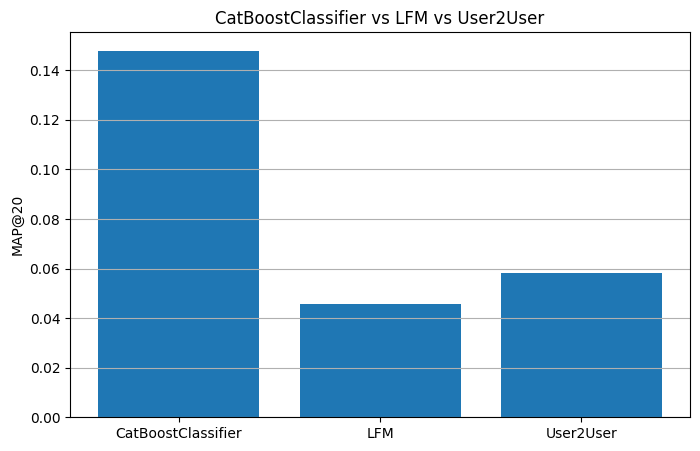

In [40]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪

X_train = train_rank_df.drop(columns=['user_id', 'target'])
y_train = train_rank_df['target']

X_test = test_rank_df.drop(columns=['user_id', 'target'])
y_test = test_rank_df['target']


clf = catboost.CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    verbose=100,
    random_seed=52
)

clf.fit(
    X_train,
    y_train,
    cat_features=['track_id']
)


def mapk_from_ranked_df(df, k=20):
    relevant = []
    predicted = []

    for user_id, user_data in df.groupby('user_id'):
        rel_tracks = user_data.loc[user_data['target'] == 1, 'track_id'].tolist()

        if len(rel_tracks) == 0:
            continue

        relevant.append(rel_tracks)
        predicted.append(user_data.sort_values('score', ascending=False)['track_id'].tolist())

    return mapk(relevant, predicted, k)


cat_test_df = test_rank_df.copy()
cat_test_df['score'] = clf.predict_proba(X_test)[:, 1]
catboost_map20 = mapk_from_ranked_df(cat_test_df, k=20)


lfm_test_df = test_rank_df.copy()

users = lfm_test_df['user_id'].to_numpy()
tracks = lfm_test_df['track_id'].to_numpy()

lfm_test_df['score'] = np.sum(model.P[users] * model.Q[tracks], axis=1)
lfm_map20 = mapk_from_ranked_df(lfm_test_df, k=20)


u2u_test_df = test_rank_df.copy()

u2u_score_dict = {}

for user_id in u2u_test_df['user_id'].unique():
    similars = obj.similarity(obj.R[user_id])
    mask = similars >= obj.alpha

    similars = similars[mask]
    neighbors = obj.R[mask]

    user_scores = np.sum(similars[:, None] * neighbors, axis=0) / np.sum(similars)
    u2u_score_dict[user_id] = user_scores

u2u_test_df['score'] = [u2u_score_dict[user_id][track_id] for user_id, track_id in zip(u2u_test_df['user_id'], u2u_test_df['track_id'])]
u2u_map20 = mapk_from_ranked_df(u2u_test_df, k=20)


results = pd.DataFrame({
    'model': ['CatBoostClassifier', 'LFM', 'User2User'],
    'MAP@20': [catboost_map20, lfm_map20, u2u_map20]
})

print(results)

plt.figure(figsize=(8, 5))
plt.bar(results['model'], results['MAP@20'])
plt.ylabel('MAP@20')
plt.title('CatBoostClassifier vs LFM vs User2User')
plt.grid(axis='y')
plt.show()

---
Как мы видим, результаты получилось значительно улучшить, потому что catboost обучается уже на готовых кандидатах в небольшом количестве, а также потому что у него намного больше признаков, которые он может комбинировать и учитывать

---

**Задание 12 (1 балл)**

Обучите `CatBoostRanker`, выбрав подходящую функцию ранжирования из тех, которые были рассмотрены на лекции. Проделайте все те же действия, что и с `CatBoostClassifier` и сравните результаты.

Groupwise loss function. OneHotMaxSize set to 10
0:	test: 0.0113603	best: 0.0113603 (0)	total: 64.4ms	remaining: 32.1s
100:	test: 0.0727920	best: 0.0735493 (68)	total: 5.76s	remaining: 22.8s
200:	test: 0.0686359	best: 0.0735493 (68)	total: 11.7s	remaining: 17.4s
300:	test: 0.0740780	best: 0.0745057 (270)	total: 17.6s	remaining: 11.6s
400:	test: 0.0801293	best: 0.0801293 (400)	total: 23.4s	remaining: 5.78s
499:	test: 0.0751793	best: 0.0801293 (400)	total: 29.2s	remaining: 0us

bestTest = 0.08012928566
bestIteration = 400

Shrink model to first 401 iterations.
                model    MAP@20
0      CatBoostRanker  0.190922
1  CatBoostClassifier  0.147962
2                 LFM  0.045861
3           User2User  0.058344


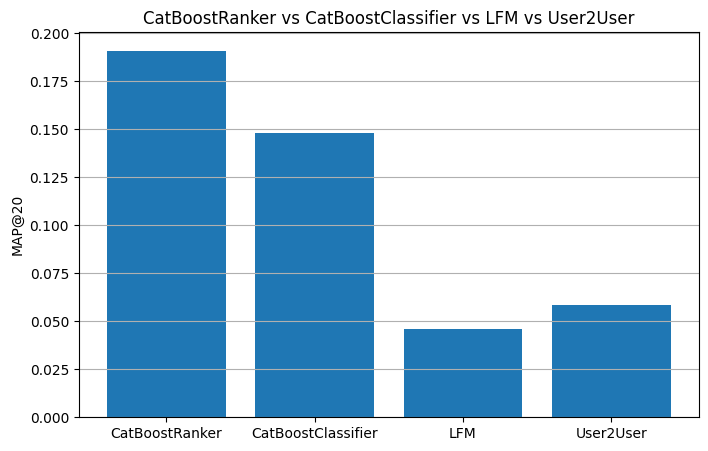

In [41]:
# your code here: (￣▽￣)/♫•*¨*•.¸¸♪

ranker = catboost.CatBoostRanker(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='YetiRank',
    verbose=100,
    random_seed=67
)

ranker.fit(train_pool, eval_set=test_pool)

rank_test_df = test_rank_df.copy()
rank_test_df['score'] = ranker.predict(test_pool)

ranker_map20 = mapk_from_ranked_df(rank_test_df, k=20)

results = pd.DataFrame({
    'model': ['CatBoostRanker', 'CatBoostClassifier', 'LFM', 'User2User'],
    'MAP@20': [ranker_map20, catboost_map20, lfm_map20, u2u_map20]
})

print(results)

plt.figure(figsize=(8, 5))
plt.bar(results['model'], results['MAP@20'])
plt.ylabel('MAP@20')
plt.title('CatBoostRanker vs CatBoostClassifier vs LFM vs User2User')
plt.grid(axis='y')
plt.show()

Как мы видим, CatBoostRanker оказался лучше, чем все остальные модели. Так получилось, потому что он учитывает относительный порядок треков внутри пользователя и учится поднимать релевантные треки в верхнюю часть рекомендаций. Предыдущий же наш catboost просто предсказывает вероятность того, что трек релевантный и не ранжирует треки относительно друг друга. То есть просто благодаря тому, что ranker напрямую оптимизирует задачу ранжирования, его результаты выше по метрике MAP@20.